# 04 :  Modélisation Machine Learning

Ce notebook couvre la modélisation prédictive du projet.

**Approche :**
- Étape 1 : Classification multi-classes (4 conditions)
- Étape 2 : Classification binaire (Depression vs reste)
- Comparaison de plusieurs modèles et sélection du meilleur

**Dataset :** `data/processed/mental_health_cleaned.csv`

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

# Outils de preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Modèles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Métriques d'évaluation
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score)

# On se place à la racine du projet
os.chdir("..")

# Chargement du dataset nettoyé
df = pd.read_csv(os.path.join("data", "processed", "mental_health_cleaned.csv"))

print(f" Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Conditions : {df['Mental Health Condition'].unique()}")

FileNotFoundError: [Errno 2] No such file or directory: 'data\\processed\\mental_health_cleaned.csv'

In [ ]:
#  1. Copie du dataframe pour ne pas modifier l'original
df_ml = df.copy()

#  2. Encodage des variables catégorielles
# LabelEncoder convertit les catégories en entiers (ex: Low=0, Medium=1, High=2)
categorical_cols = ["Country", "Gender", "Exercise Level", 
                    "Diet Type", "Stress Level"]

le = LabelEncoder()
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])
    print(f" {col} encodé")

# 3. Encodage de la variable cible
df_ml["Mental Health Condition"] = le.fit_transform(
    df_ml["Mental Health Condition"]
)

# Mapping pour se souvenir des correspondances
conditions = df["Mental Health Condition"].unique()
mapping = {i: cond for i, cond in enumerate(
    sorted(df["Mental Health Condition"].unique())
)}
print(f"\nMapping de la variable cible : {mapping}")

# 4. Séparation features / cible
X = df_ml.drop(columns=["Mental Health Condition"])
y = df_ml["Mental Health Condition"]

print(f"\nFeatures : {list(X.columns)}")
print(f"Variable cible : Mental Health Condition")
print(f"Taille X : {X.shape}")

 Country encodé
 Gender encodé
 Exercise Level encodé
 Diet Type encodé
 Stress Level encodé

Mapping de la variable cible : {0: 'Anxiety', 1: 'Bipolar', 2: 'Depression', 3: 'PTSD'}

Features : ['Country', 'Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours', 'Stress Level', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']
Variable cible : Mental Health Condition
Taille X : (2405, 11)


In [ ]:
# Split 80% train / 20% test
# stratify=y : proportions des classes identiques dans train et test
# random_state=42 : résultats reproductibles (même split à chaque exécution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

#  Normalisation des variables numériques
# On fit le scaler UNIQUEMENT sur le train pour éviter le data leakage
# (le test ne doit pas influencer la normalisation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform seulement, pas fit

print(f" Split effectué :")
print(f"   Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")

 Split effectué :
   Train : 1924 lignes (80%)
   Test  : 481 lignes (20%)


In [ ]:
print("=== ÉTAPE 1 : CLASSIFICATION MULTI-CLASSES ===\n")

# Dictionnaire des modèles à comparer
# max_iter=1000 pour la régression logistique : augmente le nb d'itérations
# pour assurer la convergence sur des données complexes
models = {
    "Logistic Regression" : LogisticRegression(
        max_iter=1000, random_state=42
    ),
    "Decision Tree"       : DecisionTreeClassifier(
        random_state=42
    ),
    "Random Forest"       : RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
    "Gradient Boosting"   : GradientBoostingClassifier(
        n_estimators=100, random_state=42
    )
}

# Stockage des résultats
results_multiclass = {}

for name, model in models.items():
    # Entraînement sur les données normalisées
    model.fit(X_train_scaled, y_train)
    
    # Prédiction sur le jeu de test
    y_pred = model.predict(X_test_scaled)
    
    # Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    
    # Validation croisée (5 folds) pour un score plus robuste
    cv_scores = cross_val_score(model, X_train_scaled, y_train, 
                                cv=5, scoring="accuracy")
    
    results_multiclass[name] = {
        "accuracy"  : accuracy,
        "f1_score"  : f1,
        "cv_mean"   : cv_scores.mean(),
        "cv_std"    : cv_scores.std()
    }
    
    print(f" {name}")
    print(f"   Accuracy     : {accuracy:.4f}")
    print(f"   F1-Score     : {f1:.4f}")
    print(f"   CV Accuracy  : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n")

=== ÉTAPE 1 : CLASSIFICATION MULTI-CLASSES ===

 Logistic Regression
   Accuracy     : 0.2827
   F1-Score     : 0.2717
   CV Accuracy  : 0.2355 (+/- 0.0126)

 Decision Tree
   Accuracy     : 0.2308
   F1-Score     : 0.2285
   CV Accuracy  : 0.2391 (+/- 0.0206)

 Random Forest
   Accuracy     : 0.2432
   F1-Score     : 0.2433
   CV Accuracy  : 0.2339 (+/- 0.0108)

 Gradient Boosting
   Accuracy     : 0.2432
   F1-Score     : 0.2410
   CV Accuracy  : 0.2386 (+/- 0.0135)



=== COMPARAISON DES MODÈLES (Multi-classes) ===



,accuracy,f1_score,cv_mean,cv_std
Decision Tree,0.2308,0.2285,0.2391,0.0206
Gradient Boosting,0.2432,0.2410,0.2386,0.0135
Logistic Regression,0.2827,0.2717,0.2355,0.0126
Random Forest,0.2432,0.2433,0.2339,0.0108


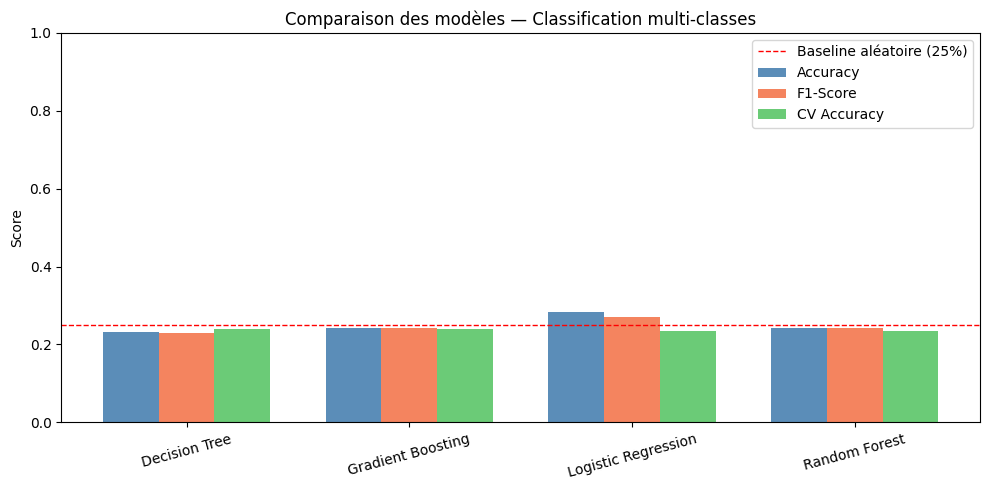

In [ ]:
# Création du tableau comparatif
results_df = pd.DataFrame(results_multiclass).T
results_df = results_df.sort_values("cv_mean", ascending=False)

print("=== COMPARAISON DES MODÈLES (Multi-classes) ===\n")
display(results_df.round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(results_df))
width = 0.25

bars1 = ax.bar([i - width for i in x], results_df["accuracy"], 
               width, label="Accuracy", color="#5B8DB8")
bars2 = ax.bar(x, results_df["f1_score"], 
               width, label="F1-Score", color="#F4845F")
bars3 = ax.bar([i + width for i in x], results_df["cv_mean"], 
               width, label="CV Accuracy", color="#6BCB77")

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles — Classification multi-classes")
ax.legend()
ax.set_ylim(0, 1)

# Ligne de référence : score aléatoire pour 4 classes = 25%
ax.axhline(y=0.25, color="red", linestyle="--", 
           linewidth=1, label="Baseline aléatoire (25%)")
ax.legend()
plt.tight_layout()
plt.show()

=== MEILLEUR MODÈLE : Decision Tree ===

Rapport de classification :
              precision    recall  f1-score   support

     Anxiety       0.20      0.16      0.18       126
     Bipolar       0.21      0.22      0.21       114
  Depression       0.23      0.24      0.23       116
        PTSD       0.27      0.30      0.29       125

    accuracy                           0.23       481
   macro avg       0.23      0.23      0.23       481
weighted avg       0.23      0.23      0.23       481



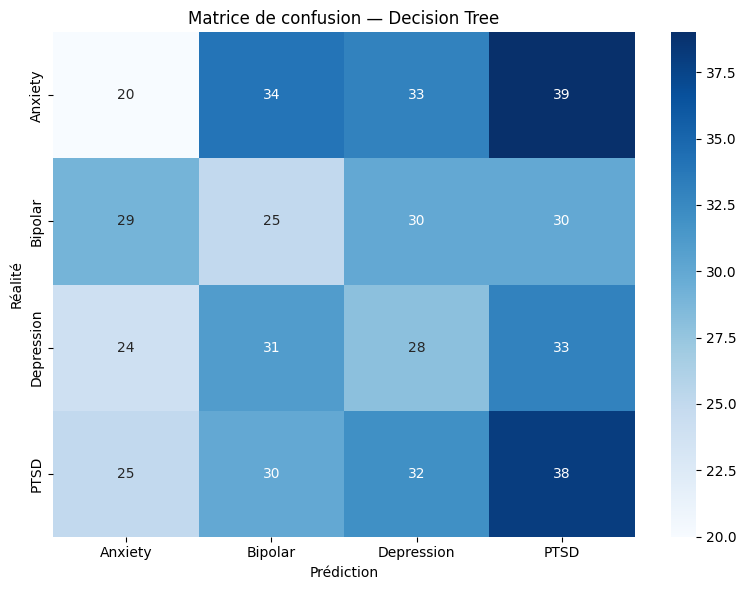

In [ ]:
# Sélection du meilleur modèle selon CV Accuracy
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"=== MEILLEUR MODÈLE : {best_model_name} ===\n")

# Rapport de classification détaillé
print("Rapport de classification :")
print(classification_report(y_test, y_pred_best, 
                            target_names=list(mapping.values())))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,           # Afficher les valeurs
    fmt="d",              # Format entier
    cmap="Blues",
    xticklabels=list(mapping.values()),
    yticklabels=list(mapping.values()),
    ax=ax
)
ax.set_title(f"Matrice de confusion — {best_model_name}")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

=== FEATURE IMPORTANCE ===



,Feature,Importance
1,Age,0.1531
10,Happiness Score,0.1378
5,Sleep Hours,0.1361
9,Social Interaction Score,0.1174
8,Screen Time per Day (Hours),0.1138
7,Work Hours per Week,0.0936
0,Country,0.0739
2,Gender,0.0528
4,Diet Type,0.0523
3,Exercise Level,0.0365


C:\Users\PC\AppData\Local\Temp\ipykernel_19560\1656143781.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


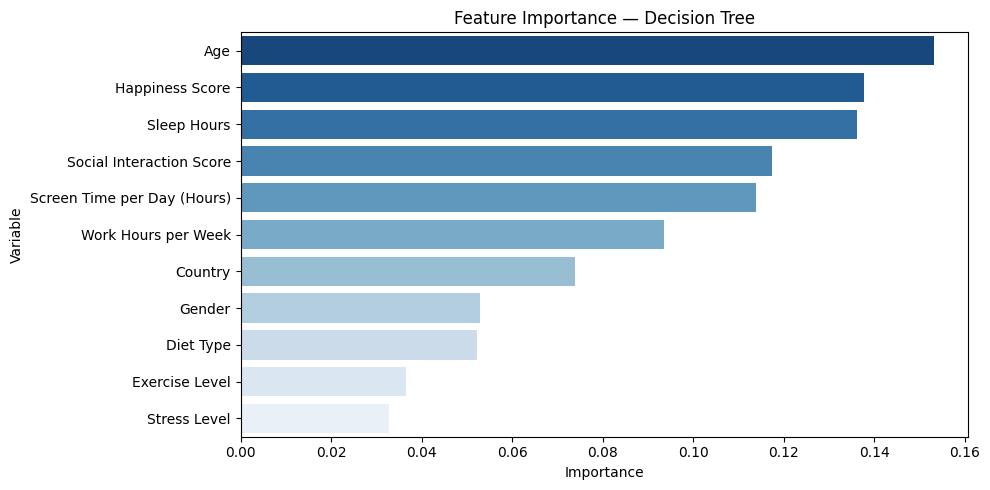

In [ ]:
# Feature importance selon le type de modèle
# - Random Forest, Gradient Boosting, Decision Tree → feature_importances_
# - Logistic Regression → coef_ (coefficients moyens en valeur absolue)

tree_based_models = ["Random Forest", "Gradient Boosting", "Decision Tree"]

if best_model_name in tree_based_models:
    # Tous les modèles basés sur des arbres ont feature_importances_
    importances = best_model.feature_importances_
else:
    # Uniquement pour la Régression Logistique
    importances = np.abs(best_model.coef_).mean(axis=0)

# Création du dataframe de feature importance
feat_importance_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Importance" : importances
}).sort_values("Importance", ascending=False)

print("=== FEATURE IMPORTANCE ===\n")
display(feat_importance_df.round(4))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=feat_importance_df,
    x="Importance",
    y="Feature",
    palette="Blues_r",
    ax=ax
)
ax.set_title(f"Feature Importance — {best_model_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("Variable")
plt.tight_layout()
plt.show()

In [ ]:
print("=== ÉTAPE 2 : CLASSIFICATION BINAIRE ===\n")

# Création de la variable cible binaire
# 1 = Depression, 0 = tout le reste (Anxiety, PTSD, Bipolar)
df_binary = df.copy()
df_binary["is_depressed"] = (
    df_binary["Mental Health Condition"] == "Depression"
).astype(int)

print(f"Distribution binaire :")
print(df_binary["is_depressed"].value_counts())
print(f"\nTaux de dépression : {df_binary['is_depressed'].mean()*100:.1f}%")

# Encodage des features (même logique qu'avant)
for col in categorical_cols:
    df_binary[col] = LabelEncoder().fit_transform(df_binary[col])

X_bin = df_binary.drop(columns=["Mental Health Condition", "is_depressed"])
y_bin = df_binary["is_depressed"]

# Split et normalisation
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)
X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)

# Entraînement et comparaison
results_binary = {}
for name, model in models.items():
    model.fit(X_train_b_scaled, y_train_b)
    y_pred_b = model.predict(X_test_b_scaled)
    accuracy_b = accuracy_score(y_test_b, y_pred_b)
    f1_b = f1_score(y_test_b, y_pred_b)
    cv_b = cross_val_score(model, X_train_b_scaled, y_train_b, 
                           cv=5, scoring="accuracy")
    
    results_binary[name] = {
        "accuracy" : accuracy_b,
        "f1_score" : f1_b,
        "cv_mean"  : cv_b.mean()
    }
    print(f" {name} — Accuracy: {accuracy_b:.4f} | F1: {f1_b:.4f} | CV: {cv_b.mean():.4f}")

=== ÉTAPE 2 : CLASSIFICATION BINAIRE ===

Distribution binaire :
is_depressed
0    1825
1     580
Name: count, dtype: int64

Taux de dépression : 24.1%
 Logistic Regression — Accuracy: 0.7588 | F1: 0.0000 | CV: 0.7588
 Decision Tree — Accuracy: 0.6216 | F1: 0.2479 | CV: 0.6346
 Random Forest — Accuracy: 0.7547 | F1: 0.0000 | CV: 0.7547
 Gradient Boosting — Accuracy: 0.7422 | F1: 0.0159 | CV: 0.7484


In [ ]:
# Création du dossier models s'il n'existe pas
os.makedirs("models", exist_ok=True)

# Sauvegarde du meilleur modèle multi-classes
joblib.dump(best_model, "models/best_model.pkl")

# Sauvegarde du scaler (nécessaire pour transformer les nouvelles données)
joblib.dump(scaler, "models/scaler.pkl")

# Sauvegarde du mapping des classes
joblib.dump(mapping, "models/class_mapping.pkl")

print(" Modèle sauvegardé : models/best_model.pkl")
print(" Scaler sauvegardé : models/scaler.pkl")
print(" Mapping sauvegardé : models/class_mapping.pkl")

 Modèle sauvegardé : models/best_model.pkl
 Scaler sauvegardé : models/scaler.pkl
 Mapping sauvegardé : models/class_mapping.pkl


## Conclusions de la modélisation

### Classification multi-classes
- **Meilleur modèle** : Decision Tree (CV Accuracy : 0.2391)
- **Scores globaux** : tous les modèles oscillent entre 23% et 28% d'accuracy,
  au niveau de la baseline aléatoire (25% pour 4 classes équilibrées)
- **Observation** : la Logistic Regression obtient la meilleure accuracy brute 
  (28.27%) mais souffre d'overfitting, sa CV Accuracy chute à 23.55%. 
  Le Decision Tree est le plus stable. Aucun modèle ne dépasse significativement 
  le hasard, ce qui confirme l'absence de signal discriminant dans les données.
- **Matrice de confusion** : le modèle tend à sur-prédire PTSD et peine 
  particulièrement sur Anxiety (recall = 16%). Les 4 classes sont massivement 
  confondues les unes avec les autres.
- **Feature Importance** : Age (0.1531), Happiness Score (0.1378) et Sleep Hours 
  (0.1361) sont les variables les plus utilisées par le modèle. Paradoxalement, 
  Stress Level (0.0328) et Exercise Level (0.0365) pourtant bien documentés 
  comme facteurs de risque dans la littérature arrivent en dernière position.

### Classification binaire (Depression vs reste)
- **Distribution** : 1825 non-dépressifs (75.9%) vs 580 dépressifs (24.1%):dataset déséquilibré
- **Meilleur modèle** : Decision Tree (F1 : 0.2479 | CV Accuracy : 0.6346)
- **Observation critique** : Logistic Regression et Random Forest atteignent 
  ~75% d'accuracy mais avec un F1-Score de 0.0000, ils ont appris à toujours 
  prédire "non-dépressif" pour profiter de la classe majoritaire. Seul le 
  Decision Tree détecte réellement des cas de dépression au prix d'une accuracy 
  plus basse (62%).
- **Comparaison multi vs binaire** : la simplification en binaire n'améliore 
  pas les performances réelles elle crée un nouveau problème de déséquilibre 
  de classes. L'approche multi-classes reste plus honnête intellectuellement.

### Limites
- Les performances sont limitées par la nature synthétique du dataset
- L'absence de corrélations réelles entre variables rend la classification 
  difficile les modèles ne dépassent pas le niveau du hasard en multi-classes
- Le déséquilibre de classes en binaire (76/24) piège les modèles dans une 
  stratégie de prédiction majoritaire (F1=0)
- Ces résultats auraient pu être améliorés avec des techniques comme SMOTE 
  (rééquilibrage) ou class_weight='balanced', mais les limites fondamentales 
  du dataset synthétique resteraient présentes
- Les résultats sont illustratifs et ne constituent pas des conclusions cliniques

### Prochaine étape
- Développement de l'application Streamlit (`app.py`)